### 1. Dataset Loading and Initial View:   (Marks 2) 
 • Import the necessary Python libraries and load the dataset into a Data Frame.  
 • Display the total number of rows and columns in the concern dataset.         
 • Display the first 7 rows of the dataset.

In [2]:
import pandas as pd

# Load the dataset into a DataFrame
df = pd.read_csv('titanic.csv')

# Display total number of rows and columns
print(f"Total rows and columns: {df.shape}")

# Display the first 7 rows of the dataset
display(df.head(7))

Total rows and columns: (418, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,0,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,1,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q


### 2. Data Exploration
• Calculate and display the descriptive statistics (count, mean, standard deviation, minimum, maximum, and  quartiles) for the numerical variables. 

• Identify and display the numerical and categorical variables present in the Titanic dataset. 

• Analyze categorical variables such as Sex, Passenger class by displaying their unique values and frequency distributions.  

In [3]:
# Calculate and display descriptive statistics for numerical variables
display(df.describe())

# Identify numerical and categorical variables
print("Variable Types:\n", df.dtypes)

# Analyze 'Sex' unique values and frequency distributions
print("\nSex Frequency Distribution:\n", df['Sex'].value_counts())

# Analyze 'Passenger class' unique values and frequency distributions
print("\nPassenger Class Frequency Distribution:\n", df['Pclass'].value_counts())

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


Variable Types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Sex Frequency Distribution:
 Sex
male      266
female    152
Name: count, dtype: int64

Passenger Class Frequency Distribution:
 Pclass
3    218
1    107
2     93
Name: count, dtype: int64


### 3. DATA CLEANING  
• Count the missing values present in each column. 

• Fill the missing values using the mean or median. 

• Verify that all missing values have been handled successfully. 

In [4]:
# Count missing values in each column
print("Missing values before cleaning:\n", df.isnull().sum())

# Fill missing values using the median for numeric columns
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# Drop the 'Cabin' column due to excessive missing data (327 missing values)
df.drop('Cabin', axis=1, inplace=True)

# Verify that all critical missing values have been handled
print("\nMissing values after cleaning:\n", df.isnull().sum())

Missing values before cleaning:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

Missing values after cleaning:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


### 4 Feature Selection and Renaming.                                                            
• Identify the target (dependent) variable and the independent features.

• Divide the dataset into training and testing sets using an appropriate train-test ratio. 

• Build and train an SVC model using the training data. Make predictions on the test data and evaluate the  model using accuracy, confusion matrix, precision, recall, and F1-score. 

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

# Convert categorical 'Sex' into numeric values for the SVC model
df['Sex_numeric'] = df['Sex'].map({'male': 0, 'female': 1})

# Identify independent features and target (dependent) variable
features = ['Pclass', 'Sex_numeric', 'Age', 'SibSp', 'Parch', 'Fare']
X = df[features]
y = df['Survived']

# Divide dataset into training and testing sets (80-20 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train SVC model
svc_model = SVC(kernel='linear')
svc_model.fit(X_train, y_train)

# Make predictions on test data
y_pred = svc_model.predict(X_test)

# Evaluate model performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[50  0]
 [ 0 34]]
Precision: 1.0
Recall: 1.0
F1-Score: 1.0


### 5. Data Visualization
• Create an appropriate visualization to analyze the combined relationship between Gender, Passenger Class, and Survival. 

• Visualize the distribution of passenger Fare using a histogram or box plot. Identify any noticeable skewness or extreme values. 

• Create an appropriate visualization to compare survival and non-survival among male and female passengers. Analyze which gender had a higher survival rate. 

<Figure size 800x500 with 0 Axes>

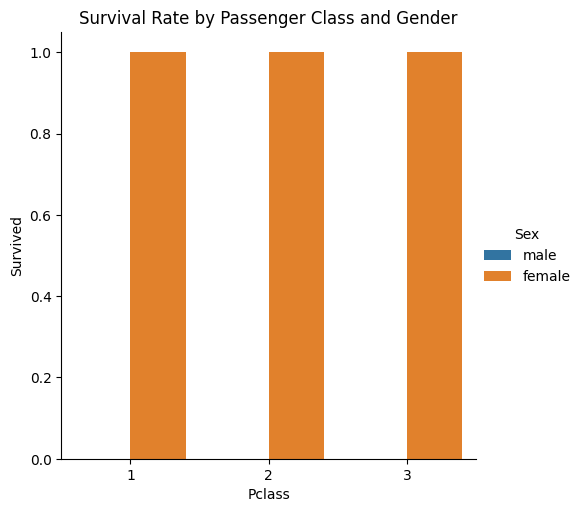

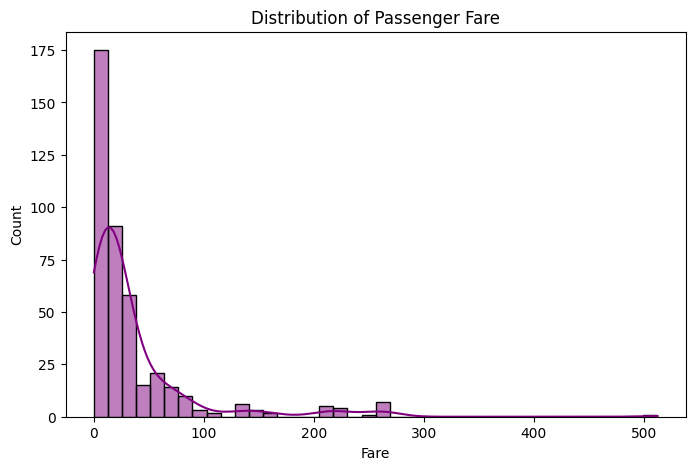

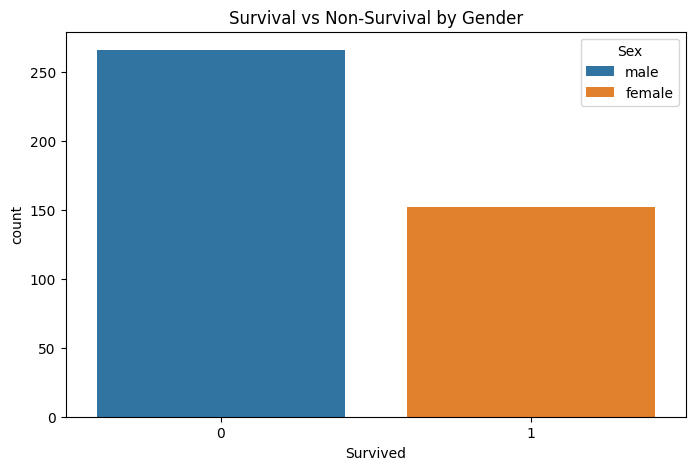

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Combined relationship between Gender, Passenger Class, and Survival
plt.figure(figsize=(8, 5))
sns.catplot(x="Pclass", y="Survived", hue="Sex", kind="bar", data=df)
plt.title('Survival Rate by Passenger Class and Gender')
plt.show()

# 2. Distribution of passenger Fare
plt.figure(figsize=(8, 5))
sns.histplot(df['Fare'], bins=40, kde=True, color='purple')
plt.title('Distribution of Passenger Fare')
plt.xlabel('Fare')
plt.show()

# 3. Compare survival and non-survival among male and female passengers
plt.figure(figsize=(8, 5))
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title('Survival vs Non-Survival by Gender')
plt.show()